##### Подгрузка библиотек

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
import matplotlib._color_data as mcd
from sklearn import datasets
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, robust_scale
plt.style.use('ggplot')

##### Дополнительные функции

In [45]:
def add_15(arr):
    return arr+15

def add_4(arr):
    return arr+4

#### KMeans

**Алгоритм действий:** 
1. Определение K случайных центров в пространстве признаков. Каждый объект выборки относят к тому кластеру, к центру которого объект оказался ближе.
2. Центры кластеров пересчитывают как среднее арифметическое векторов признаков всех вошедших в этот кластер объектов. 
3. После обновления центроидов объекты заново перераспределяются по ним и повторяется 2 шаг. Процесс продолжается до тех пор, пока центры кластеров не перестанут меняться (или до поставленного в алгоритме ограничения). <br>
[Источник](https://academy.yandex.ru/handbook/ml/article/klasterizaciya)

**Как оптимизируем:** уменьшаем средний квадрат евклидова расстояния от объектов до центроидов кластеров. <br>
$\Phi_0 = \frac{1}{nK} \sum\limits_{k=1}^{K} \sum\limits_{i=1}^{n} (\mu_k - x_i)^2 \mathbb{I}[a(x_i)=k]$

**Параметры:**


1.   **n_clusters** - количество кластеров, на которые будут разделены объекты выборки. Чаще всего определяется с помощью метода локтя (также дополнительно к методу локтя на график можно накладывать Коэффициент силуэта (silhoette score)). 
2.   **n_init** (default=10) - алгоритм будет инициализировать различные группы центроидов 10 раз. Если в init прописано расположение центроидов, то n_init будет установлено на 1. 
3.   **max_iter** (default=300) - количество итераций kmeans при каждой установки центроидов n_init раз. На каждом шаге объектам будут назначаться различные кластеры и будет пересчитываться инерция ( сумма квадрата расстояния по каждому обьекту до ближайшего центроида) 
4.   **init** - расположение центроидов кластеров. Если нам известно примерное расположение центроидов кластера, то в init можно записывать их расположение. Это может помочь, если вы понимаете, что примерно хотите получить от кластеризации. 
5. **random_state** - стоит определять random_state, чтобы была возможность переиспользовать (при повторном запуске) разбиение на кластеры



##### **Подготовка данных**

Определим три кластера с заданными матожиданием и стандартным отклонением.  <br> Также добавим два кластера с нестандартным распределением с центром в (15, 4). <br>
В каждом кластере будет находиться по 1000 объектов.

In [46]:
mean1, mean2, mean3a, mean3b = 5, 10, 1, 6
sigma1, sigma2, sigma3a, sigma3b = 1, 2, 0.8, 0.4
n = 1000
np.random.seed(42)
x1 = np.random.normal(mean1, sigma1, n)
y1 = np.random.normal(mean1, sigma1, n)
x2 = np.random.normal(mean2, sigma2, n)
y2 = np.random.normal(mean2, sigma2, n)
x3 = np.random.normal(mean3a, sigma3a, n)
y3 = np.random.normal(mean3b, sigma3b, n)

In [47]:
xy4, correct_cluster = datasets.make_circles(n_samples=n*2, factor=0.5, noise=0.05)

In [48]:
df_circles = pd.DataFrame(list(zip(xy4, correct_cluster)), columns=['x_y','group'])
df_circles[['X', 'Y']] = pd.DataFrame(df_circles.x_y.tolist(), index= df_circles.index)
df_circles[['X']], df_circles[['Y']] = df_circles[['X']].apply(add_15), df_circles[['Y']].apply(add_4)
df_circles.drop('x_y', axis=1, inplace=True)

df_circles0 = df_circles[df_circles['group'] == 0]
df_circles1 = df_circles[df_circles['group'] == 1]

In [49]:
df1 = pd.DataFrame(list(zip(x1, y1)), columns=['X','Y'])
df1['group'] = 0
df2 = pd.DataFrame(list(zip(x2, y2)), columns=['X','Y'])
df2['group'] = 1
df3 = pd.DataFrame(list(zip(x3, y3)), columns=['X','Y'])
df3['group'] = 2
df_circles0['group'] = 3
df_circles1['group'] = 4
df = pd.concat([df1, df2, df3, df_circles0, df_circles1])
df = df.reset_index(drop=True)
df.groupby('group').count()

,X,Y
group,,
0,1000,1000
1,1000,1000
2,1000,1000
3,1000,1000
4,1000,1000


Визуализируем данные. <br>
Сложнее всего будет выделить кластеры в форме кругов.

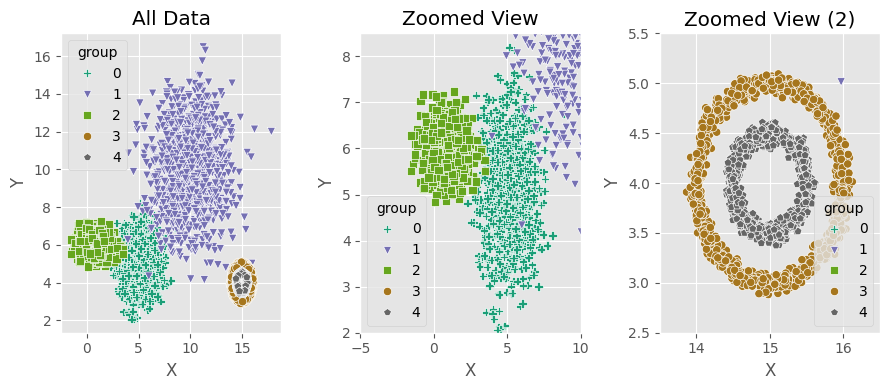

In [50]:
cmap = mpl.colormaps['Dark2']
temp_df = df.copy(deep=True)
fig, ax = plt.subplots(1,3, figsize=(9, 4), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=temp_df, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['P', 'v', 's', 'o', 'p'], ax=ax[0])
ax[0].set_title('All Data')
ax[1] = sns.scatterplot(data=temp_df, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['P', 'v', 's', 'o', 'p'], ax=ax[1])
ax[1].set_xlim([-5,10])
ax[1].set_ylim([2,8.5])
ax[1].set_title('Zoomed View')

ax[2] = sns.scatterplot(data=temp_df, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['P', 'v', 's', 'o', 'p'], ax=ax[2])
ax[2].set_xlim([13.5,16.5])
ax[2].set_ylim([2.5,5.5])
ax[2].set_title('Zoomed View (2)')
plt.show()

##### **Стандартизируем фичи!**
При работе с эвклидовым расстоянием необходимо для лучшего разбиения на кластеры <br>
**z = (x - u) / s** <br>
где u - среднее значение по признаку (или 0 если with_mean=False), s - стандартное отклонение признака (или 1 если with_std=False)
Для стандартизации будем использовать **StandardScaler()**

![img](https://miro.medium.com/max/1012/1*PM2Fgh4bm6RB0sNgxsjalw.jpeg)

In [51]:
temp_df = df.copy(deep=True)
scl = StandardScaler()
temp_arr = (temp_df.loc[:, temp_df.columns != 'group']).values
dfnorm = scl.fit_transform(temp_arr)
dfnorm = pd.DataFrame(dfnorm, columns=['X', 'Y'])

In [52]:
km = KMeans(n_clusters=5, random_state=42).fit(dfnorm)
dfnorm['pred'] = km.labels_
dfnorm = dfnorm.merge(temp_df, left_index=True, right_index=True)
dfnorm.columns= ['X_norm','Y_norm', 'pred', 'X', 'Y', 'group']

##### **Кластеризация**

1. **Первая попытка** разбить объекты на кластеры прошла не успешно, мы не смогли распознать нижние кластеры, формирующие круги и вместо этого разбили большой кластер на две части. Будем пытаться найти эти кластеры.

In [53]:
temp_df = dfnorm.copy(deep=True)
km = KMeans(n_clusters=5, random_state=42).fit(temp_df.loc[:, ['X_norm', 'Y_norm']])
km.cluster_centers_
temp_df['pred'] = km.labels_

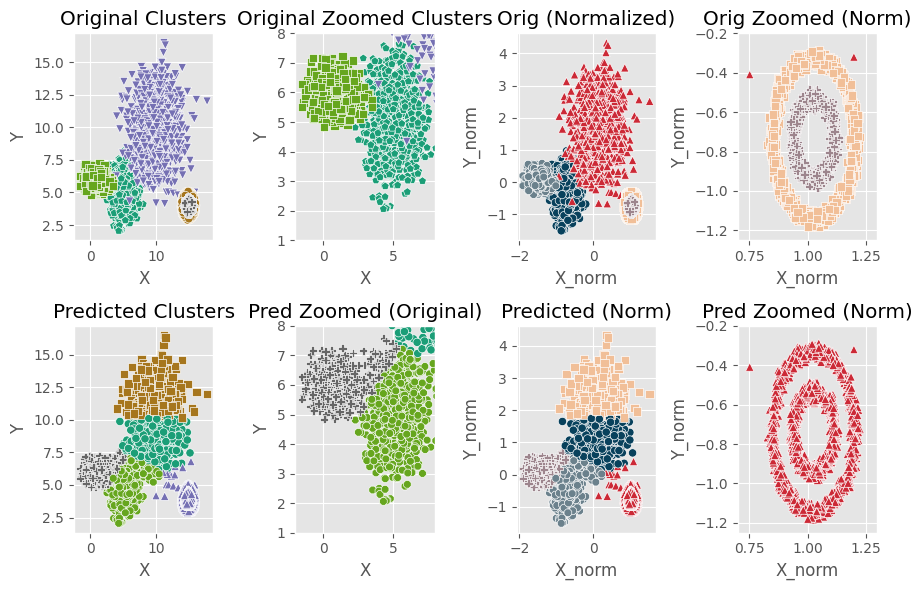

In [54]:
palette = ['#08415C', '#CC2936', '#6B818C', '#F1BF98', '#9D858D']
palette1 = ['#9D858D', '#BBA0B2', '#A4A8D1', '#A4BFEB']

fig, ax = plt.subplots(2, 4, figsize=(9, 6), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=dfnorm, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'o', 'P'], ax=ax[0])
ax[1] = sns.scatterplot(data=dfnorm, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'o', 'P'], ax=ax[1])
ax[2] = sns.scatterplot(data=dfnorm, x='X_norm', y='Y_norm', hue='group', palette=palette, style='group', markers=['o', '^', '8', 's', 'P'], ax=ax[2])
ax[3] = sns.scatterplot(data=dfnorm, x='X_norm', y='Y_norm', hue='group', palette=palette, style='group', markers=['o', '^', '8', 's', 'P'], ax=ax[3])
ax[4] = sns.scatterplot(data=dfnorm, x='X', y='Y', hue='pred', palette=cmap, style='pred', markers=['o', '^', '8', 's', 'P'], ax=ax[4])
ax[5] = sns.scatterplot(data=dfnorm, x='X', y='Y', hue='pred', palette=cmap, style='pred', markers=['o', '^', '8', 's', 'P'], ax=ax[5])
ax[6] = sns.scatterplot(data=dfnorm, x='X_norm', y='Y_norm', hue='pred', palette=palette, style='pred', markers=['o', '^', '8', 's', 'P'], ax=ax[6])
ax[7] = sns.scatterplot(data=dfnorm, x='X_norm', y='Y_norm', hue='pred', palette=palette, style='pred', markers=['o', '^', '8', 's', 'P'], ax=ax[7])

ax[1].set_xlim([-2,8])
ax[1].set_ylim([1,8])
ax[3].set_xlim([0.7,1.3])
ax[3].set_ylim([-1.25,-0.2])
ax[5].set_xlim([-2,8])
ax[5].set_ylim([1,8])
ax[7].set_xlim([0.7,1.3])
ax[7].set_ylim([-1.25,-0.2])
titles = ['Original Clusters', 'Original Zoomed Clusters', 'Orig (Normalized)', 'Orig Zoomed (Norm)', \
          'Predicted Clusters', 'Pred Zoomed (Original)', 'Predicted (Norm)', 'Pred Zoomed (Norm)']

for ind in range(8):
    ax[ind].set_title(titles[ind])
    ax[ind].get_legend().remove()

plt.show()

2. **Вторая попытка**. **Укажем два параметра:** `max_iter` & `n_init`. <br>
Увеличим как параметр `n_init` (чтобы попытаться найти нижний кластер) и `max_iter`
**Пометка:** <br>`max_iter` (default=300) - количество итераций kmeans при каждой установки центроидов n_init раз. На каждом шаге объектам будут назначаться различные кластеры и будет пересчитываться инерция ( сумма квадрата расстояния по каждому обьекту до ближайшего центроида)   <br>

`n_init` (default=10) - алгоритм будет инициализировать различные группы центроидов 10 раз. Если в init прописано расположение центроидов, то n_init будет установлено на 1. 



In [55]:
temp_df = dfnorm.copy(deep=True)
km = KMeans(n_clusters=5, max_iter=1000, n_init=15, random_state=42).fit(dfnorm.loc[:, ['X_norm', 'Y_norm']])
temp_df['pred'] = km.labels_

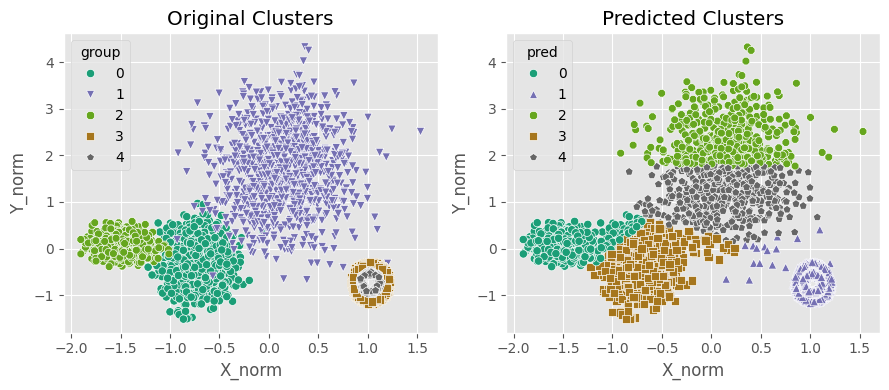

In [56]:
fig, ax = plt.subplots(1,2, figsize=(9, 4), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['o', 'v', '8', 's', 'p'], ax=ax[0])
ax[1] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='pred', palette=cmap, style='pred', markers=['o', '^', '8', 's', 'p'], ax=ax[1])
ax[0].set_title('Original Clusters')
ax[1].set_title('Predicted Clusters')
plt.show()

Все еще не получается разбить нижний кластер, попробуем использовать другие способы

![img](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRfa0syJbpFiN2up9oY23f4J0is-ISeEGR6kiko1B2l_Y_-1BtMR4aVZoJs3MpzW95Hxyo&usqp=CAU)

##### Если известно **приближенное расположение центроидов** (что бывает не часто), его можно прописывать в `init` (в таком случае `n_init` будет установлен как 1)

In [57]:
df_centr = pd.concat([df1, df2, df3, df_circles0, df_circles1])
df_centr = df.reset_index(drop=True)
 #df_centr.groupby('group').count()

Если мы сместим расположение одного из кластеров, которые мы не можем разбить, то алгоритм его распознает. Если центроиды будут равны (как и есть в данном случае), то он все еще будет определяться как один кластер 

In [58]:
centroids = np.asarray([[-0.8,-0.9], [0.3,1.8], [-1.5,0], [1,-0.8], [1,-0.7]]) # попробуйте заменить последнее значение -0.7 на -0.8
dftmp = temp_df.copy(deep=True)
dftmp = dftmp[['X_norm', 'Y_norm', 'group']]
km = KMeans(n_clusters=5, init=centroids, random_state=42).fit(dftmp.loc[:, dftmp.columns != 'group'])
km.cluster_centers_
dftmp['pred'] = km.labels_

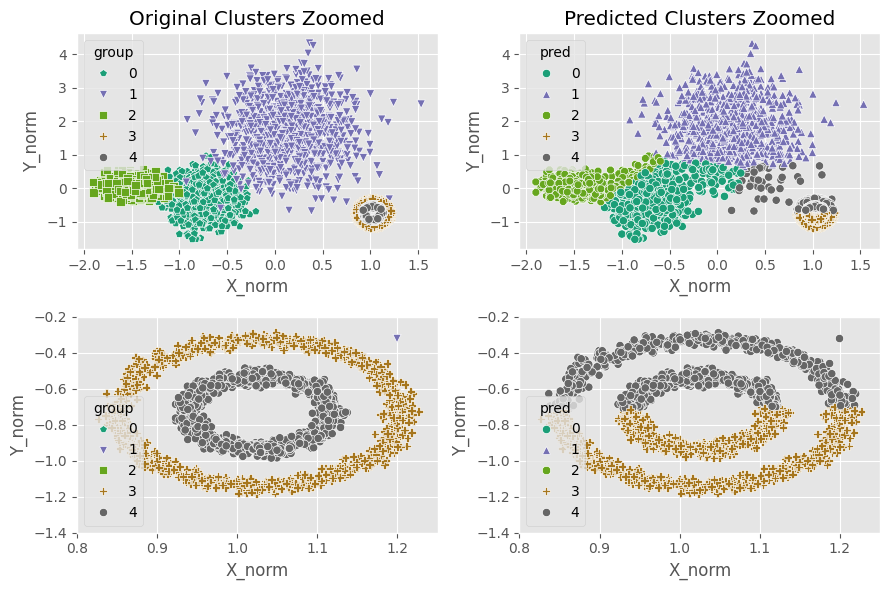

In [59]:
fig, ax = plt.subplots(2,2, figsize=(9, 6), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=dftmp, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'P', 'o'], ax=ax[0])
ax[1] = sns.scatterplot(data=dftmp, x='X_norm', y='Y_norm', hue='pred', palette=cmap, style='pred', markers=['o', '^', '8', 'P', 'o'], ax=ax[1])
ax[2] = sns.scatterplot(data=dftmp, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'P', 'o'], ax=ax[2])
ax[2].set_xlim([0.8,1.25])
ax[2].set_ylim([-1.4,-0.2])
ax[3] = sns.scatterplot(data=dftmp, x='X_norm', y='Y_norm', hue='pred', palette=cmap, style='pred', markers=['o', '^', '8', 'P', 'o'], ax=ax[3])
ax[3].set_xlim([0.8,1.25])
ax[3].set_ylim([-1.4,-0.2])
ax[0].set_title('Original Clusters')
ax[1].set_title('Predicted Clusters')
ax[0].set_title('Original Clusters Zoomed')
ax[1].set_title('Predicted Clusters Zoomed')
plt.show()

Не смотря на то, что установка центроидов не позволила правильно разбить нижний кластер, он хотя бы его нашел и не стал разбивать кластер выше. Успех!

МЕМ

##### **Добавим больше кластеров** <br>
Этот подход позволит разделить кластеры, которые не были разбиты ранее (в нашем случае - нижние).  <br>
Увеличием количество кластеров вдвое.

In [60]:
temp_df = dfnorm.copy(deep=True)
numclusters = 5 * 2
km = KMeans(n_clusters=numclusters, random_state=42).fit(temp_df.loc[:, ['X_norm', 'Y_norm']])
km.cluster_centers_
temp_df['pred'] = km.labels_
clus_cols = [ii[1] for ii in list(mcd.XKCD_COLORS.items())[0:numclusters]]

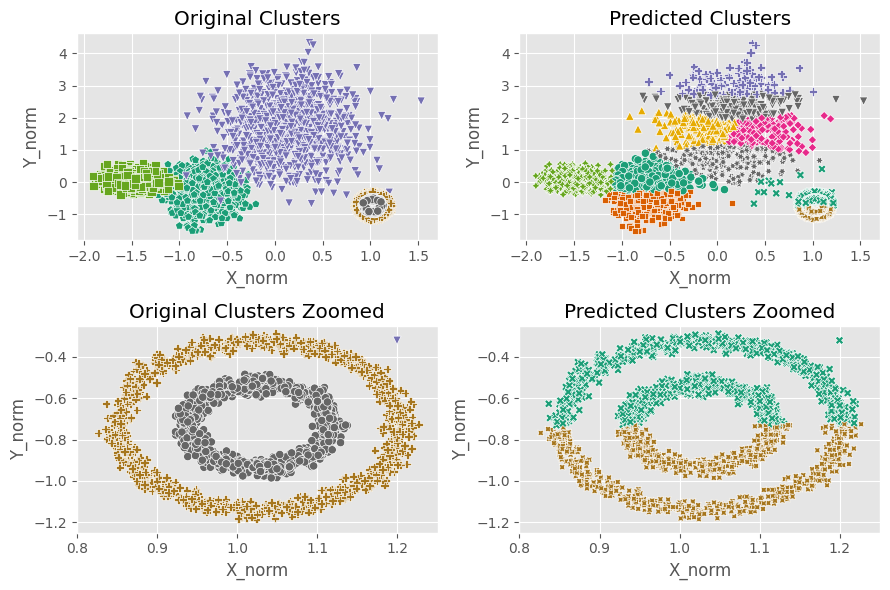

In [61]:
fig, ax = plt.subplots(2,2, figsize=(9, 6), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'P', 'o'], ax=ax[0])
ax[1] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='pred', palette=cmap, style='pred', ax=ax[1])
ax[2] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['p', 'v', 's', 'P', 'o'], ax=ax[2])
ax[3] = sns.scatterplot(data=temp_df, x='X_norm', y='Y_norm', hue='pred', palette=cmap, style='pred', ax=ax[3])
ax[2].set_xlim([0.8,1.25])
ax[2].set_ylim([-1.25,-0.25])
ax[3].set_xlim([0.8,1.25])
ax[3].set_ylim([-1.25,-0.25])
ax[0].set_title('Original Clusters')
ax[1].set_title('Predicted Clusters')
ax[2].set_title('Original Clusters Zoomed')
ax[3].set_title('Predicted Clusters Zoomed')
ax[0].get_legend().remove()
ax[1].get_legend().remove()
ax[2].get_legend().remove()
ax[3].get_legend().remove()
plt.tight_layout()

Следующим этапом было бы объединение излишне разбитых кластеров. <br> 

Да, кластер был разбит, однако все еще не так, как нам нужно (это сделать Kmeans не сможет, для более нестандартных форм кластеров мы будем использовать **DBSCAN**)

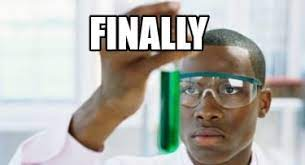

#### DBSCAN

**Parameters:**


1.    **eps**: радиус эпсилон-окрестности. Максимальное расстояние между двумя образцами, при котором один считается соседним с другим. Это не максимальная граница расстояний между точками внутри кластера. Это самый важный параметр DBSCAN, который следует подбирать под каждый набора данных и функцию расстояния индивидально.
2.   **min_samples**: количество соседей. Объект считается корневым, если рядом с ним находится `min_samples` внутри установленного eps


**The steps for the DBSCAN algorithm are:**

1. Выберите пороговое значение расстояния (**eps**) и минимальное количество выборок (**min_samples**), которые определяют плотную область. <br>
2. Для каждой выборки в наборе данных найдите все остальные выборки, находящиеся на расстоянии `eps`. Если в пределах этого расстояния есть хотя бы **min_samples**, образец является "ключевым образцом". <br>
3. Если образец является образцом керна, назначьте все образцы в пределах расстояния в секунду тому же кластеру, что и образец керна. <br>
4. Если образец не является образцом керна, но находится на расстоянии в секунду от образца керна, отнесите его к тому же кластеру, что и образец керна.<br>
5. Повторяйте процесс для всех оставшихся сэмплов, пока все сэмплы не будут отнесены к кластеру или помечены как шум (сэмплы, не принадлежащие ни к одному кластеру).


Плюсы алгоритма: 
1. Мы не должны определять количество кластеров (что мы должны делать Kmeans) 
2. Может определять шум (и можем его выбрасывать) 
3. Мы можем определять функцию расстояния без переписывания самой функции (что мы должны делать с Kmeans)
4. Алгоритм может определять кластеры различных форм и самостоятельно опредеелять кол-во кластеров

Минусы: 
1. Мы не можем получить информацию о расположении центроидов

Посмотрим, как DBSCAN справляется с кругами

In [62]:
temp_df = dfnorm.copy(deep=True)
circles_df = temp_df[(temp_df['group'] == 3 ) | ( temp_df['group'] == 4)]

Without any added parameters we didn't get acceptable clusters (we need 5, not 2). We'll change **eps** and **min_samples** to change it 

Без установки дополнительных параметров мы не получаем необходимое кол-во кластеров (`eps` слишком большой для разбиения кругов)

In [63]:
db = DBSCAN().fit(circles_df.loc[:, ['X_norm', 'Y_norm']])
labels = db.labels_
circles_df['pred'] = labels

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 1
Estimated number of noise points: 0


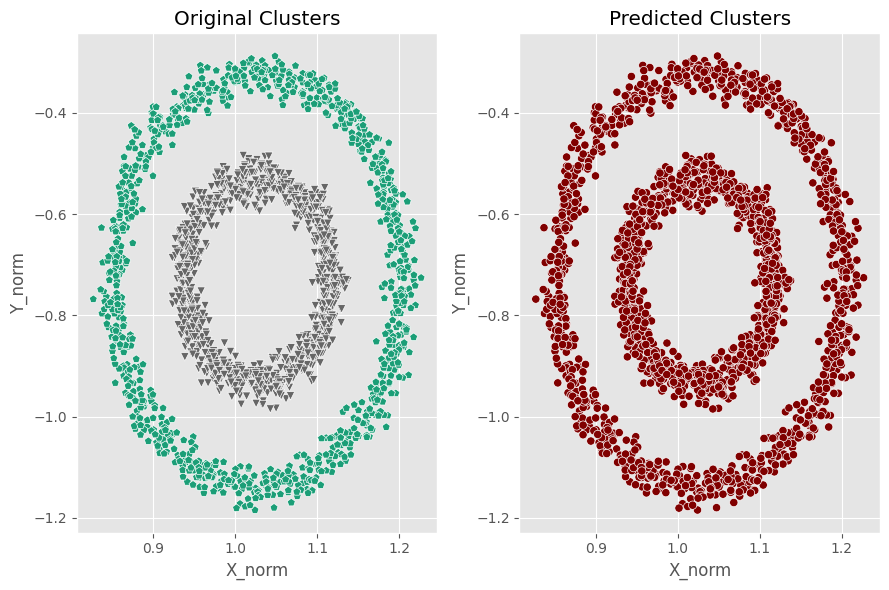

In [64]:
fig, ax = plt.subplots(1,2, figsize=(9, 6), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=circles_df, x='X_norm', y='Y_norm', hue='group', palette=cmap, style='group', markers=['p', 'v'], ax=ax[0])
ax[1] = sns.scatterplot(data=circles_df, x='X_norm', y='Y_norm', hue='pred', palette=['maroon'], style='pred', ax=ax[1])

ax[0].set_title('Original Clusters')
ax[1].set_title('Predicted Clusters')

ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.show()

Уменьшим `eps` до 0.02 (чтобы снизить расстояние, которое будем прооверять на наличие соседей)


In [65]:
db = DBSCAN(eps=0.02).fit(circles_df.loc[:, ['X_norm', 'Y_norm']])
labels = db.labels_
circles_df['pred'] = labels

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 1


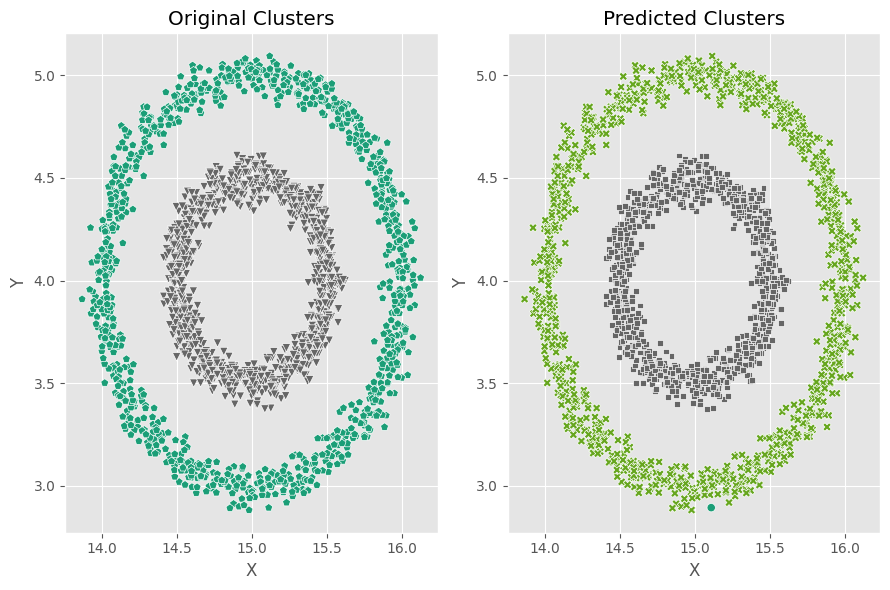

In [66]:
fig, ax = plt.subplots(1,2, figsize=(9, 6), tight_layout=True)
ax = ax.flatten()
ax[0] = sns.scatterplot(data=circles_df, x='X', y='Y', hue='group', palette=cmap, style='group', markers=['p', 'v'], ax=ax[0])
ax[1] = sns.scatterplot(data=circles_df, x='X', y='Y', hue='pred', palette=cmap, style='pred', ax=ax[1])

ax[0].set_title('Original Clusters')
ax[1].set_title('Predicted Clusters')

ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.tight_layout()

О, класс! У нас получилось разбить круги на два отдельных кластера. 

![img](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRLKRlmvZvckTen22P4sMQrO5xOjdlce6n1_A&usqp=CAU)